<a href="https://colab.research.google.com/github/ysfcorp/ysfcorp/blob/main/Indian_Stock_Time_Series_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
df = pd.read_csv("/nifty500_stocks.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (219800, 8)


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,RELIANCE,202.593277,203.896194,201.987518,202.959000,189.999802,2963643
1,2015-01-02,RELIANCE,203.004715,204.821960,202.136108,202.421829,189.496948,7331366
2,2015-01-05,RELIANCE,202.296112,203.644760,199.804550,200.204575,187.421234,10103941
3,2015-01-06,RELIANCE,198.867371,199.553116,190.181198,191.118393,178.915237,18627980
4,2015-01-07,RELIANCE,191.346985,196.307236,191.324127,195.278610,182.809814,20720312


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219800 entries, 0 to 219799
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       219800 non-null  object 
 1   Symbol     219800 non-null  object 
 2   Open       219800 non-null  float64
 3   High       219800 non-null  float64
 4   Low        219800 non-null  float64
 5   Close      219800 non-null  float64
 6   Adj Close  219800 non-null  float64
 7   Volume     219800 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 13.4+ MB

Missing values:
Date         0
Symbol       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [5]:
df.columns.tolist()

['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

In [ ]:
print("Number of unique stocks:", df["Symbol"].nunique())

print("\nFirst 20 stocks:")
print(df["Symbol"].unique()[:20])

In [7]:
print("RELIANCE" in df["Symbol"].values)

True


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Symbol", "Date"])

print(df["Date"].min())
print(df["Date"].max())

2015-01-01 00:00:00
2023-12-29 00:00:00


In [9]:
stock = df[df["Symbol"] == "RELIANCE"].copy()

stock = stock.sort_values("Date")

print("Rows:", len(stock))
stock.head()

Rows: 2221


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,RELIANCE,202.593277,203.896194,201.987518,202.959000,189.999802,2963643
1,2015-01-02,RELIANCE,203.004715,204.821960,202.136108,202.421829,189.496948,7331366
2,2015-01-05,RELIANCE,202.296112,203.644760,199.804550,200.204575,187.421234,10103941
3,2015-01-06,RELIANCE,198.867371,199.553116,190.181198,191.118393,178.915237,18627980
4,2015-01-07,RELIANCE,191.346985,196.307236,191.324127,195.278610,182.809814,20720312


In [10]:
stock.tail()

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
2216,2023-12-22,RELIANCE,1279.800049,1290.449951,1273.824951,1282.525024,1273.102173,16541784
2217,2023-12-26,RELIANCE,1284.000000,1295.974976,1281.349976,1289.025024,1279.554443,7465664
2218,2023-12-27,RELIANCE,1291.000000,1299.949951,1286.550049,1293.425049,1283.922119,9204156
2219,2023-12-28,RELIANCE,1294.900024,1306.000000,1293.425049,1302.775024,1293.203369,12302636
2220,2023-12-29,RELIANCE,1305.550049,1307.000000,1289.650024,1292.474976,1282.979126,10864584


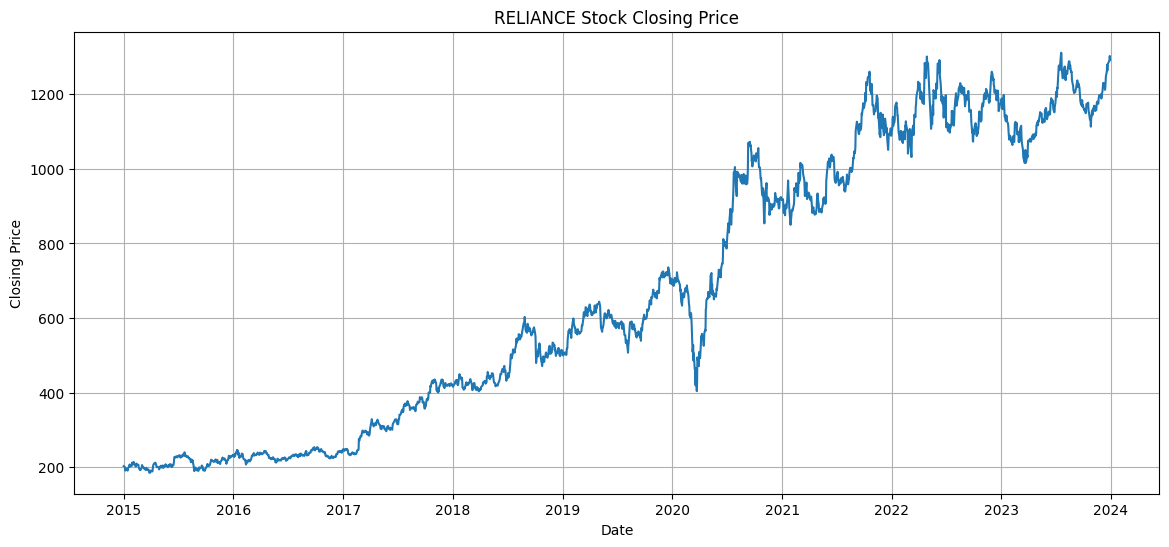

In [11]:
plt.figure(figsize=(14, 6))

plt.plot(stock["Date"], stock["Close"])

plt.title("RELIANCE Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

In [12]:
# Create lag and moving-average features

stock["Previous_Close"] = stock["Close"].shift(1)

stock["MA_7"] = stock["Close"].rolling(window=7).mean()

stock["MA_14"] = stock["Close"].rolling(window=14).mean()

stock["MA_30"] = stock["Close"].rolling(window=30).mean()

# Target = next day's closing price
stock["Target"] = stock["Close"].shift(-1)

# Remove rows created with NaN values
stock = stock.dropna()

stock.head()

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume,Previous_Close,MA_7,MA_14,MA_30,Target
29,2015-02-12,RELIANCE,207.553528,208.913589,202.810425,207.816391,194.547028,8709626,205.884872,207.388622,207.750272,202.689658,209.725067
30,2015-02-13,RELIANCE,208.925018,210.479385,207.793533,209.725067,196.333847,7393680,207.816391,207.019623,208.249890,202.915193,206.364899
31,2015-02-16,RELIANCE,209.999359,211.256577,205.724854,206.364899,193.188248,12266698,209.725067,206.337139,208.474391,203.046629,206.102020
32,2015-02-18,RELIANCE,205.724854,207.553528,204.444794,206.102020,192.942139,9835036,206.364899,206.067736,208.389489,203.243210,206.193451
33,2015-02-19,RELIANCE,207.313507,207.462097,202.878998,206.193451,193.027725,9550637,206.102020,206.242438,207.942935,203.745712,199.575974


In [13]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Previous_Close",
    "MA_7",
    "MA_14",
    "MA_30"
]

X = stock[features]
y = stock["Target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
          Open        High         Low       Close    Volume  Previous_Close  \
29  207.553528  208.913589  202.810425  207.816391   8709626      205.884872   
30  208.925018  210.479385  207.793533  209.725067   7393680      207.816391   
31  209.999359  211.256577  205.724854  206.364899  12266698      209.725067   
32  205.724854  207.553528  204.444794  206.102020   9835036      206.364899   
33  207.313507  207.462097  202.878998  206.193451   9550637      206.102020   

          MA_7       MA_14       MA_30  
29  207.388622  207.750272  202.689658  
30  207.019623  208.249890  202.915193  
31  206.337139  208.474391  203.046629  
32  206.067736  208.389489  203.243210  
33  206.242438  207.942935  203.745712  

Target:
29    209.725067
30    206.364899
31    206.102020
32    206.193451
33    199.575974
Name: Target, dtype: float64


In [15]:
split_index = int(len(stock) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1752
Testing samples: 439


In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [17]:
y_pred = model.predict(X_test)

print("First 10 predictions:")

for actual, predicted in zip(y_test.iloc[:10], y_pred[:10]):
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f}")

First 10 predictions:
Actual: 1171.84 | Predicted: 1168.04
Actual: 1190.05 | Predicted: 1172.73
Actual: 1197.98 | Predicted: 1189.93
Actual: 1210.03 | Predicted: 1198.68
Actual: 1210.31 | Predicted: 1209.56
Actual: 1233.57 | Predicted: 1209.95
Actual: 1215.94 | Predicted: 1233.60
Actual: 1225.67 | Predicted: 1216.13
Actual: 1229.30 | Predicted: 1226.52
Actual: 1211.92 | Predicted: 1230.26


In [18]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
------------------------
MAE  : 11.74
MSE  : 251.97
RMSE : 15.87
R²   : 0.9331


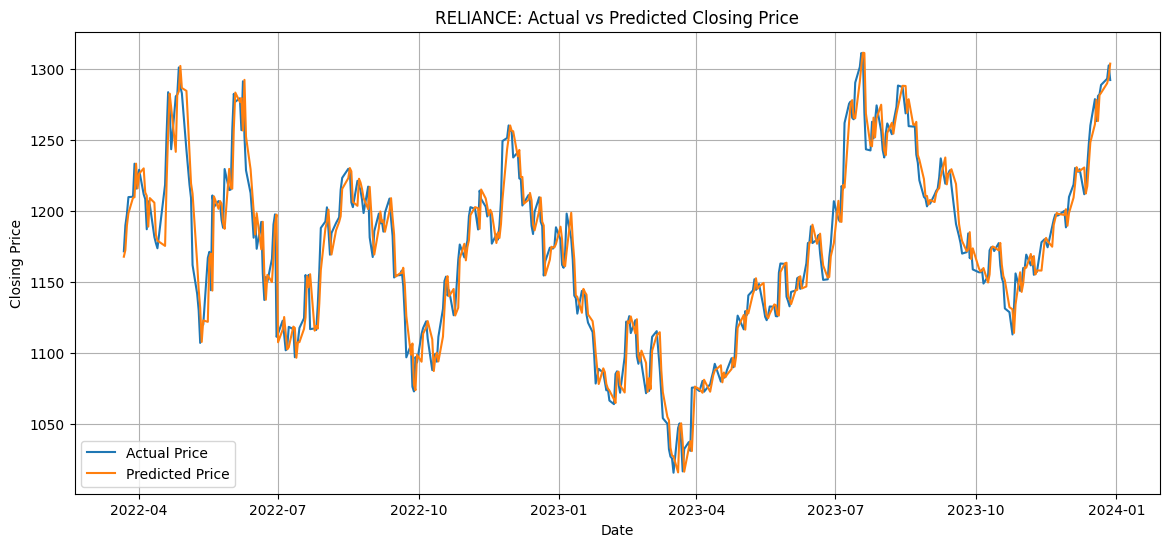

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(stock["Date"].iloc[split_index:], y_test.values,
         label="Actual Price")

plt.plot(stock["Date"].iloc[split_index:], y_pred,
         label="Predicted Price")

plt.title("RELIANCE: Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
print("Model Performance")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Performance
------------------------
MAE  : 11.74
MSE  : 251.97
RMSE : 15.87
R²   : 0.9331


In [22]:
# Baseline: predict tomorrow's price as today's closing price

baseline_pred = stock["Close"].iloc[split_index:].values

baseline_actual = stock["Target"].iloc[split_index:].values

print("Length of predictions:", len(baseline_pred))
print("Length of actual values:", len(baseline_actual))

baseline_mae = mean_absolute_error(baseline_actual, baseline_pred)

baseline_mse = mean_squared_error(baseline_actual, baseline_pred)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(baseline_actual, baseline_pred)

print("\nBaseline Performance")
print("------------------------")
print(f"MAE  : {baseline_mae:.2f}")
print(f"MSE  : {baseline_mse:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

Length of predictions: 439
Length of actual values: 439

Baseline Performance
------------------------
MAE  : 11.67
MSE  : 250.77
RMSE : 15.84
R²   : 0.9334


In [23]:
print("Linear Regression Performance")
print("------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
------------------------------
MAE  : 11.74
MSE  : 251.97
RMSE : 15.87
R²   : 0.9331
